In [1]:
from gstatot import sweep_utils
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set_style('ticks')
sns.set_context('paper', font_scale=1.5)

In [2]:
import glob
results_dir = f'./sweep_res'
os.makedirs('./sweep_res/final_figures', exist_ok=True)

results_files = glob.glob(f'{results_dir}/*.csv')
res = pd.DataFrame()
for f in results_files:
    res = pd.concat([res, pd.read_csv(f, index_col=0)], ignore_index=True) 

In [3]:
gsot_cmap = sns.color_palette("Blues", as_cmap=True)
sot_cmap = sns.color_palette("Purples", as_cmap=True)
pba_cmap = sns.color_palette("Greens", as_cmap=True)

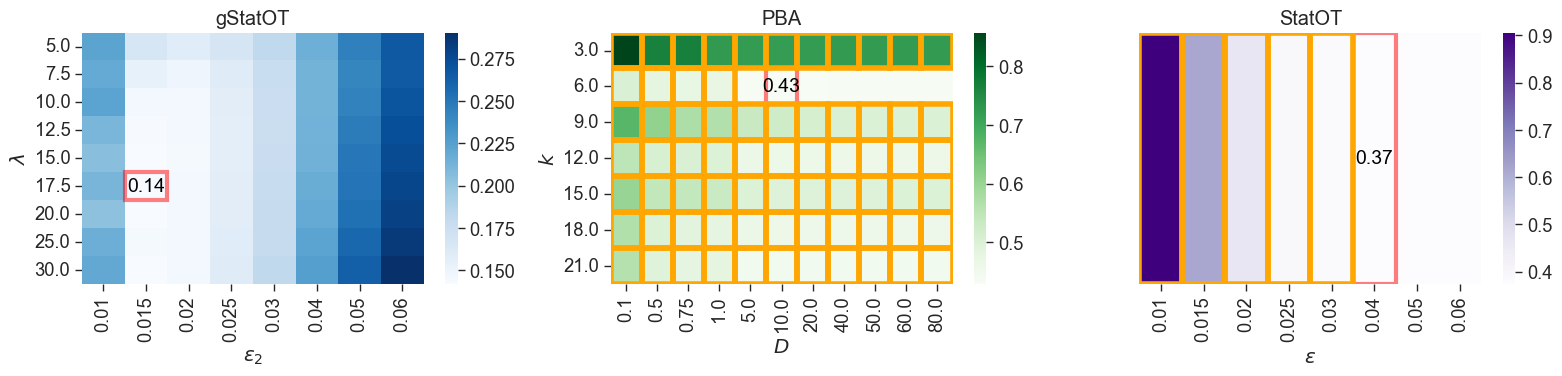

: 

In [ ]:
figsize = 4
gStatOT_opt_vals = {}
StatOT_opt_vals = {}
PBA_opt_vals = {}

fig, axs = plt.subplots(1, 3, figsize=(figsize * 4, figsize * 1), sharex='col', )

res_df_gStatOT = res[res['method'] == 'gStatOT']
res_df_StatOT = res[res['method'] == 'StatOT']
res_df_PBA = res[res['method'] == 'PBA']

ax1 = axs[0] 
vmin = None
vmax = None
lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                     metric='FP_TV_dist', title='gStatOT',  
                                     cbar=True,
                                     input_ax=ax1,
                                     vminmax=(vmin, vmax),
                                     highlight_nans=True,
                                     cmap=gsot_cmap)
ax1.set_ylabel(r'$\lambda$')
ax1.set_xlabel(r'$\epsilon_2$')
gStatOT_opt_vals[0] = (lam, epsilon2)


ax3 = axs[2]
_, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                     metric='FP_TV_dist', title='StatOT',
                                     cbar=True,
                                     input_ax=ax3,
                                     vminmax=(vmin, vmax), 
                                     highlight_nans=True,
                                     cmap=sot_cmap)
ax3.set_xlabel(r'$\epsilon$')
ax3.set_ylabel('')
ax3.set_yticks([])
StatOT_opt_vals[0] = epsilon

ax2 = axs[1]
k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                     metric='FP_TV_dist', title='PBA',
                                     cbar=True,
                                     input_ax=ax2,
                                     vminmax=(vmin, vmax), 
                                     highlight_nans=True,
                                     cmap=pba_cmap)
ax2.set_xlabel(r'$D$')
ax2.set_ylabel(r'$k$')
ax2.tick_params(axis='y', rotation=0)
PBA_opt_vals[0] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/GRN_sim_results.png', dpi=350)
plt.show()

gStatOT_opt_vals_df = pd.DataFrame(gStatOT_opt_vals, index=['lam', 'epsilon2']).T
StatOT_opt_vals_df = pd.DataFrame(StatOT_opt_vals, index=['epsilon']).T
PBA_opt_vals_df = pd.DataFrame(PBA_opt_vals, index=['k', 'D']).T

gStatOT_opt_vals_df.to_csv('./gStatOT_opt_vals_sim.csv')
StatOT_opt_vals_df.to_csv('./StatOT_opt_vals_sim.csv')
PBA_opt_vals_df.to_csv('./PBA_opt_vals_sim.csv')